# Retraining DREIDING: refitting the generators, and testing whether they transfer

DREIDING's central claim is that a very small set of *generic* parameters,
assigned by hybridization rather than by atom pair, is enough to describe
new molecules: "the philosophy in DREIDING is to use general force
constants and geometry parameters based on simple hybridization
considerations rather than individual force constants and geometric
parameters that depend on the particular combination of atoms involved"
(Mayo, Olafson & Goddard III, *J. Phys. Chem.* **94**, 8897, 1990). Its
Conclusions then name the obvious next step: "the next level of
sophistication in developing generic force fields is to alter the
parameters (force constants, barriers) to change smoothly as a function of
rows and columns of the periodic table. We leave this to a later study."

In `xnn` every one of those generators is a tensor in a
`DreidingForceField`, so that later study is a gradient descent. Because
the valence terms are *generated* rather than tabulated, what gets refit is
not a list of bond types but the small set of numbers the rules read: the
per-element bond radius and equilibrium angle, the universal stretch and
bend force constants, and the six torsion barriers. Refitting those is the
DREIDING analogue of refitting OPLS
torsions (`examples/ffnn/opls/opls_lopls_torsion_refit.ipynb`) or ReaxFF
parameters (`examples/ffnn/reaxff/reaxff_rmd17_train_test.ipynb`).

The experiment here is deliberately a transferability test rather than a
fit quality test:

1. take the published DREIDING and measure it against PBE reference forces
   for three aromatic molecules from rMD17;
2. refit the generators **on benzene alone**;
3. ask what that did to **naphthalene** and **toluene**, which were never
   trained on. Naphthalene uses exactly benzene's atom types (`C_R`, `H_`),
   so it tests transfer of the refitted generators directly; toluene adds a
   `C_3` methyl carbon whose generators were never touched, so it tests
   whether the refit damaged anything it did not see.

If the generic parameters really are transferable, improving them on one
molecule has to improve the others too.

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")
import time
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import torch

torch.set_default_dtype(torch.float64)
torch.manual_seed(0)
rng = np.random.default_rng(0)

from ase import Atoms

import xnn
from xnn.common.data import AtomicDataset, collate, load_dataset
from xnn.common.models import ForceStressOutput
from xnn.ffnn.models import Dreiding, DreidingForceField, read_dreiding

CUTOFF = 12.0
print("xnn:", xnn.__version__, "| torch:", torch.__version__)

xnn: 0.2.0 | torch: 2.5.1+cu121


## 1. Reference data and topologies

rMD17 (Christensen & von Lilienfeld, *MLST* **1**, 045018, 2020) gives
100k configurations per molecule, sampled from MD at 500 K and recomputed at
PBE/def2-SVP. A molecular-mechanics force field with a fixed topology is
exactly the right consumer: every frame is a conformer of the same molecule.

A DREIDING model is built once per molecule from a single frame; the types
and connectivity then hold for the whole trajectory.

In [2]:
def prepare(name, n):
    '''Sample n rMD17 frames and build the matching DREIDING topology.'''
    raw = load_dataset("rmd17", molecule=name, split="train")
    sub = [raw[i] for i in rng.permutation(len(raw))[:n]]
    first = Atoms(numbers=np.asarray(sub[0]["atomic_numbers"]),
                  positions=np.asarray(sub[0]["pos"]))
    topology = Dreiding.from_atoms(first, "dreiding", cutoff=CUTOFF).topology
    ds = AtomicDataset(sub, cutoff=CUTOFF)
    return topology, [ds[i] for i in range(len(ds))]


TOPOLOGY, GRAPHS = {}, {}
for name, n in (("benzene", 500), ("toluene", 500), ("naphthalene", 300)):
    TOPOLOGY[name], GRAPHS[name] = prepare(name, n)

TRAIN = {n: collate(GRAPHS[n][:300]) for n in ("benzene", "toluene")}
TEST = {"benzene": collate(GRAPHS["benzene"][300:]),
        "toluene": collate(GRAPHS["toluene"][300:]),
        "naphthalene": collate(GRAPHS["naphthalene"])}

for name, top in TOPOLOGY.items():
    m = Dreiding("dreiding", top, cutoff=CUTOFF)
    f = TEST[name].forces
    print(f"{name:12s} {top.n_atoms:3d} atoms  types {dict(Counter(top.types))}  "
          f"bond orders {sorted(set(top.bond_orders))}  "
          f"{m.dihedral_index.shape[1]:3d} torsions  "
          f"{m.inversion_index.shape[1] // 3:2d} inversion centers  "
          f"|F|rms {float((f ** 2).mean().sqrt()):.2f} eV/A")

rmd17:benzene train:   0%|          | 0/1000 [00:00<?, ? struct/s]

rmd17:benzene test:   0%|          | 0/1000 [00:00<?, ? struct/s]

rmd17:toluene train:   0%|          | 0/1000 [00:00<?, ? struct/s]

rmd17:toluene test:   0%|          | 0/1000 [00:00<?, ? struct/s]

rmd17:naphthalene train:   0%|          | 0/1000 [00:00<?, ? struct/s]

rmd17:naphthalene test:   0%|          | 0/1000 [00:00<?, ? struct/s]

benzene       12 atoms  types {'C_R': 6, 'H_': 6}  bond orders [1.0, 1.5]   24 torsions   6 inversion centers  |F|rms 0.92 eV/A
toluene       15 atoms  types {'C_3': 1, 'C_R': 6, 'H_': 8}  bond orders [1.0, 1.5]   30 torsions   6 inversion centers  |F|rms 1.25 eV/A
naphthalene   18 atoms  types {'C_R': 10, 'H_': 8}  bond orders [1.0, 1.5]   44 torsions  10 inversion centers  |F|rms 1.33 eV/A


Benzene and naphthalene use the same two atom types, which is what makes
the transfer test clean: a generator refit on benzene is applied unchanged
to naphthalene. Toluene adds `C_3`.

## 2. One force field, three molecules

A `DreidingForceField` holds the generators; a `Dreiding` model binds one
to a topology. Passing the *same* force-field object to several models
makes them share parameters, so a gradient from any molecule updates the
generators all of them read. That is the mechanism the transfer test needs,
and it is also how one would fit a genuinely transferable parameter set
over a whole training set of different molecules.

In [3]:
# the valence generators: per-element bond radius and equilibrium angle, the
# two universal force constants, and the six torsion barriers. The van der
# Waals parameters are deliberately left frozen -- see the note below.
GROUPS = ("radius", "theta0", "bond_k", "angle_k", "torsion_v")


def make(trainable=()):
    '''A shared force field plus one model per molecule.'''
    ff = DreidingForceField("dreiding", trainable=trainable)
    return ff, {n: Dreiding(ff, t, cutoff=CUTOFF) for n, t in TOPOLOGY.items()}


def scores(model, batch):
    '''Force MAE (eV/A) and centered energy MAE (meV/atom).'''
    out = ForceStressOutput(model)(batch)
    f, e = out["forces"].detach(), out["energy"].detach()
    n = int(batch.n_atoms[0])
    f_mae = float((f - batch.forces).abs().mean())
    # DREIDING has no atomization energy, so only energy *differences* are
    # meaningful: both series are centered before comparing
    e_mae = float(((e - e.mean()) - (batch.energy - batch.energy.mean()))
                  .abs().mean()) * 1000.0 / n
    return f_mae, e_mae


ORDER = ["benzene", "toluene", "naphthalene"]
ff0, M0 = make()
n_shared = sum(p.numel() for p in DreidingForceField("dreiding", trainable=GROUPS)
               .parameters() if p.requires_grad)
print(f"models sharing one force field: {list(M0)}")
print(f"all three read the same {n_shared} generator values "
      f"(of which only the rows for the types present can receive gradients)")

models sharing one force field: ['benzene', 'toluene', 'naphthalene']
all three read the same 101 generator values (of which only the rows for the types present can receive gradients)


The van der Waals parameters are left out of the fit on purpose. Table II
of the paper sources them from crystal data -- "n-hexane crystal",
"benzene crystal", "H2O dimer", or interpolation -- because that is the
kind of observable that determines a well depth. Single-molecule gas-phase
forces contain almost no information about them: the only nonbonded pairs
inside a rigid aromatic are 1,4 and beyond, all near contact. Unfreezing
them here changes the force error by under 0.03 eV/Å and lets the optimizer
walk ``D0(C_R)`` straight through zero to a negative value, which is not a
weaker attraction but a switched-off interaction. Fit van der Waals
parameters to condensed-phase data, or not at all.

## 3. Where the published parameters stand

In [4]:
def table(tag, models, store=None):
    r = [scores(models[n], TEST[n]) for n in ORDER]
    print(f"{tag:30s}" + "".join(f"{a:9.4f} /{b:7.2f}" for a, b in r))
    if store is not None:
        store[tag] = r
    return r


results = {}
print(f"{'':30s}" + "".join(f"{n + ' F/dE':>18s}" for n in ORDER))
print(f"{'':30s}" + "".join(f"{'(eV/A) (meV/atom)':>18s}" for _ in ORDER))
print("-" * 84)
base = table("published DREIDING", M0, results)

                                    benzene F/dE      toluene F/dE  naphthalene F/dE
                               (eV/A) (meV/atom) (eV/A) (meV/atom) (eV/A) (meV/atom)
------------------------------------------------------------------------------------


published DREIDING               1.2886 /  12.39   1.0860 /  12.53   1.3325 /  14.71


Around 1.3 eV/Å of force error is what a generic force field with no
aromatic-specific parameters and no charges costs on 500 K PBE data. The
question is how much of that the generators themselves can absorb.

## 4. Refitting on benzene alone

The loss is the standard energy + force objective. One wrinkle is specific
to classical force fields: DREIDING has no atomization energy, so its
absolute energy and the DFT total energy live on different scales. The
reference energies are shifted once onto the model's scale, after which
only the *variation* is being fitted -- and the reported energy error is
always a centered one.

In [5]:
def refit(train_on, epochs=300, lr=3e-3, force_weight=10.0):
    '''Refit the shared generators on the named molecules.'''
    ff, models = make(GROUPS)
    offsets = {}
    for name in train_on:
        with torch.no_grad():
            pred = ForceStressOutput(models[name])(TRAIN[name])["energy"]
            offsets[name] = pred.mean() - TRAIN[name].energy.mean()
    opt = torch.optim.Adam([p for p in ff.parameters() if p.requires_grad], lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    history = []
    for _ in range(epochs):
        opt.zero_grad()
        loss = 0.0
        for name in train_on:
            b = TRAIN[name]
            out = ForceStressOutput(models[name])(b)
            n = int(b.n_atoms[0])
            loss = loss \
                + ((out["energy"] - (b.energy + offsets[name])) ** 2).mean() / n ** 2 \
                + force_weight * ((out["forces"] - b.forces) ** 2).mean()
        loss.backward()
        opt.step()
        sched.step()
        history.append(float(loss))
    return ff, models, history


t0 = time.time()
ff1, M1, hist1 = refit(["benzene"])
print(f"[{time.time() - t0:.0f} s]\n")
print(f"{'':30s}" + "".join(f"{n + ' F/dE':>18s}" for n in ORDER))
print("-" * 84)
table("published DREIDING", M0)
fit1 = table("refit on benzene", M1, results)
print("-" * 84)
print("force-MAE reduction:        " +
      "   ".join(f"{n} {100 * (1 - a[0] / b[0]):3.0f}%"
                 for n, a, b in zip(ORDER, fit1, base)))

[13 s]

                                    benzene F/dE      toluene F/dE  naphthalene F/dE
------------------------------------------------------------------------------------
published DREIDING               1.2886 /  12.39   1.0860 /  12.53   1.3325 /  14.71
refit on benzene                 0.1463 /   1.41   0.4732 /   8.27   0.4474 /   7.06
------------------------------------------------------------------------------------
force-MAE reduction:        benzene  89%   toluene  56%   naphthalene  66%


Benzene improves by about 90%, which is unsurprising since it was the
training molecule. The informative columns are the other two: naphthalene,
which shares benzene's atom types and was never seen, improves by about
two thirds, and toluene improves substantially as well even though its
`C_3` generators were never trained. The generic parameters do transfer.

## 5. Fitting on two molecules at once

Some generators are barely constrained by a single molecule. The clearest
case is `theta0` for `C_R`: in a planar six-ring the C-C-C angle is locked
at 120° by ring closure whatever the equilibrium value says, so benzene
alone gives the fit almost no signal about it and it drifts. Adding a
second molecule with different geometry around the same atom type ties it
down. The shared force field makes this a one-line change.

In [6]:
t0 = time.time()
ff2, M2, hist2 = refit(["benzene", "toluene"])
print(f"[{time.time() - t0:.0f} s]\n")
print(f"{'':30s}" + "".join(f"{n + ' F/dE':>18s}" for n in ORDER))
print("-" * 84)
table("published DREIDING", M0)
table("refit on benzene", M1)
fit2 = table("refit on benzene + toluene", M2, results)
print("-" * 84)
print("naphthalene is held out of both fits.\n")
for tag, fit in (("benzene only    ", fit1), ("benzene+toluene ", fit2)):
    print(f"  {tag} force-MAE reduction: " +
          "   ".join(f"{n} {100 * (1 - a[0] / b[0]):3.0f}%"
                     for n, a, b in zip(ORDER, fit, base)))

[25 s]

                                    benzene F/dE      toluene F/dE  naphthalene F/dE
------------------------------------------------------------------------------------
published DREIDING               1.2886 /  12.39   1.0860 /  12.53   1.3325 /  14.71
refit on benzene                 0.1463 /   1.41   0.4732 /   8.27   0.4474 /   7.06
refit on benzene + toluene       0.1712 /   1.96   0.3890 /   6.89   0.4659 /   7.39
------------------------------------------------------------------------------------
naphthalene is held out of both fits.

  benzene only     force-MAE reduction: benzene  89%   toluene  56%   naphthalene  66%
  benzene+toluene  force-MAE reduction: benzene  87%   toluene  64%   naphthalene  65%


## 6. What moved

Reading the refitted generators back out is the point of
`export_library`: the result is an ordinary DREIDING parameter set in the
paper's units, which can be saved, reloaded and used like any other.

In [7]:
pub = read_dreiding("dreiding")
lib1, lib2 = ff1.export_library(), ff2.export_library()
print(f"{'generator':34s} {'published':>10s} {'benzene':>10s} {'ben+tol':>10s}")
print("-" * 68)
rows = [("bond radius R0(C_R)  (A)", pub.radius["C_R"], lib1.radius["C_R"], lib2.radius["C_R"]),
        ("bond radius R0(H_)   (A)", pub.radius["H_"], lib1.radius["H_"], lib2.radius["H_"]),
        ("bond radius R0(C_3)  (A)", pub.radius["C_3"], lib1.radius["C_3"], lib2.radius["C_3"]),
        ("angle theta0(C_R)  (deg)", pub.theta0["C_R"], lib1.theta0["C_R"], lib2.theta0["C_R"]),
        ("angle theta0(C_3)  (deg)", pub.theta0["C_3"], lib1.theta0["C_3"], lib2.theta0["C_3"]),
        ("K_bond   (kcal/mol/A^2)", pub.bond_k1, lib1.bond_k1, lib2.bond_k1),
        ("K_angle (kcal/mol/rad^2)", pub.angle_k, lib1.angle_k, lib2.angle_k),
        ("V_d resonance  (kcal/mol)", pub.torsion_v["d"], lib1.torsion_v["d"], lib2.torsion_v["d"]),
        ("V_b sp2-sp3    (kcal/mol)", pub.torsion_v["b"], lib1.torsion_v["b"], lib2.torsion_v["b"]),
        ("V_a sp3-sp3    (kcal/mol)", pub.torsion_v["a"], lib1.torsion_v["a"], lib2.torsion_v["a"]),
        ("vdW D0(C_R)   (kcal/mol)", pub.vdw_d0["C_R"], lib1.vdw_d0["C_R"], lib2.vdw_d0["C_R"])]
for name, a, b, c in rows:
    print(f"{name:34s} {a:10.4f} {b:10.4f} {c:10.4f}")

print(f"\naromatic C-H equilibrium length (eq 6, R0_C + R0_H - delta):")
for tag, lib in (("published", pub), ("benzene", lib1), ("ben+tol", lib2)):
    print(f"   {tag:10s} {lib.radius['C_R'] + lib.radius['H_'] - lib.delta:.4f} A")

generator                           published    benzene    ben+tol
--------------------------------------------------------------------
bond radius R0(C_R)  (A)               0.7000     0.6995     0.6978
bond radius R0(H_)   (A)               0.3300     0.4138     0.4078
bond radius R0(C_3)  (A)               0.7700     0.7700     0.7356
angle theta0(C_R)  (deg)             120.0000   107.0683   106.6181
angle theta0(C_3)  (deg)             109.4710   109.4710   110.2473
K_bond   (kcal/mol/A^2)              700.0000   696.6889   693.3522
K_angle (kcal/mol/rad^2)             100.0000    95.1507    95.5930
V_d resonance  (kcal/mol)             25.0000    19.0053    18.7692
V_b sp2-sp3    (kcal/mol)              1.0000     1.0000    -0.0377
V_a sp3-sp3    (kcal/mol)              2.0000     2.0000     2.0000
vdW D0(C_R)   (kcal/mol)               0.0951     0.0951     0.0951

aromatic C-H equilibrium length (eq 6, R0_C + R0_H - delta):
   published  1.0200 A
   benzene    1.1033 A
   ben+

The refit keeps the universal force constants close to their published
values (they were calibrated on a far wider set than three molecules) and
spends most of its freedom on the per-element geometry: the aromatic C-H
equilibrium length moves from 1.02 to about 1.10 Å, which is where PBE puts
it, and the resonance torsion barrier softens. Two rows are controls: the frozen van der Waals
well depth, and `V_a`, the sp3-sp3 barrier, which no training molecule
contains a bond for and which therefore never moves. `V_b`, the sp2-sp3
barrier of toluene's methyl-to-ring bond, moves only in the joint fit. `theta0(C_R)` drifts well away from 120°, for the
ring-closure reason above -- a reminder that a generator being well fitted
for forces is not thereby a well-determined equilibrium geometry.

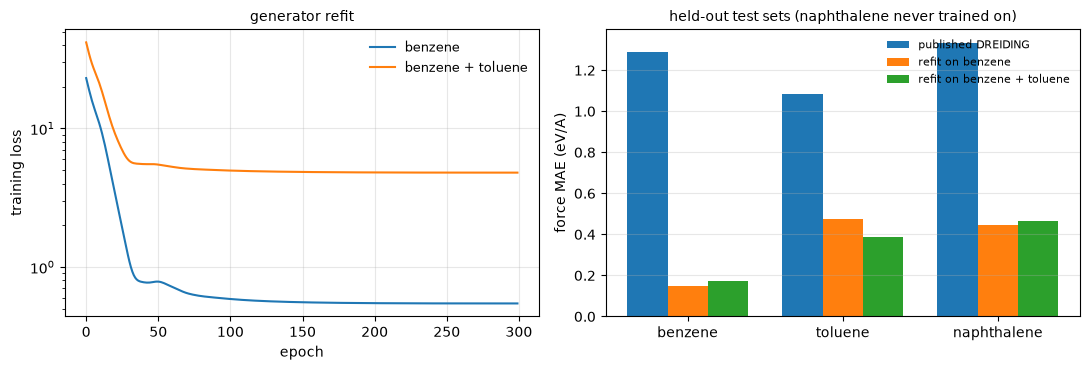

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].semilogy(hist1, lw=1.5, label="benzene")
axes[0].semilogy(hist2, lw=1.5, label="benzene + toluene")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("training loss")
axes[0].set_title("generator refit", fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].legend(frameon=False, fontsize=9)

labels = list(results)
x = np.arange(len(ORDER))
width = 0.26
for k, tag in enumerate(labels):
    axes[1].bar(x + (k - 1) * width, [results[tag][i][0] for i in range(len(ORDER))],
                width, label=tag)
axes[1].set_xticks(x)
axes[1].set_xticklabels(ORDER)
axes[1].set_ylabel("force MAE (eV/A)")
axes[1].set_title("held-out test sets (naphthalene never trained on)", fontsize=10)
axes[1].grid(alpha=0.3, axis="y")
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.savefig("dreiding_refit_aromatics.png", dpi=130, bbox_inches="tight")
plt.show()

## 7. Saving and reusing the refitted force field

A refitted `DreidingLibrary` round-trips through JSON, so a fit can be
saved and used later exactly like the shipped parameter set, including from
a YAML config (`ffield: <path>.json`).

In [9]:
import os
os.makedirs("runs", exist_ok=True)
path = lib2.save("runs/dreiding_aromatic_refit.json")

check = Dreiding(read_dreiding(path), TOPOLOGY["naphthalene"], cutoff=CUTOFF)
a = scores(check, TEST["naphthalene"])
b = scores(M2["naphthalene"], TEST["naphthalene"])
print(f"reloaded from {path}")
print(f"   naphthalene force MAE  reloaded {a[0]:.6f}  in-memory {b[0]:.6f}  "
      f"difference {abs(a[0] - b[0]):.2e} eV/A")
assert abs(a[0] - b[0]) < 1e-12
print("\nequivalent YAML config:\n")
print(f'''model:
  name: dreiding
  cutoff: {CUTOFF}
  ffield: {path}
  topology: <topology.json written by MolecularTopology.save>
  trainable: [{", ".join(GROUPS)}]''')

reloaded from runs/dreiding_aromatic_refit.json
   naphthalene force MAE  reloaded 0.465888  in-memory 0.465888  difference 0.00e+00 eV/A

equivalent YAML config:

model:
  name: dreiding
  cutoff: 12.0
  ffield: runs/dreiding_aromatic_refit.json
  topology: <topology.json written by MolecularTopology.save>
  trainable: [radius, theta0, bond_k, angle_k, torsion_v]


## 8. Summary

| force MAE | benzene (held-out frames) | toluene (never trained, in fit 1) | naphthalene (never trained) |
|---|---|---|---|
| published DREIDING | 1.29 eV/Å | 1.09 eV/Å | 1.33 eV/Å |
| refit on benzene | 0.15 (−89%) | 0.47 (−56%) | 0.45 (−66%) |
| refit on benzene + toluene | 0.17 (−87%) | 0.39 (−64%) | 0.47 (−65%) |

Refitting roughly a dozen effective generator values on a single molecule
cuts the force error on a *different, larger* molecule by about two thirds.
That is the DREIDING premise -- generic, hybridization-assigned parameters
transfer between molecules -- tested rather than assumed, and it is the
practical reason to keep the generators trainable: a DREIDING parameter set
can be retargeted to a new chemistry from a modest amount of reference
data without giving up the rule-based machinery that makes it applicable to
molecules it has never seen.

Three caveats worth carrying forward. The fit improves forces, not
necessarily equilibrium geometries: generators that a training molecule
constrains only weakly (here `theta0` of an aromatic carbon) can drift to
unphysical values while the forces improve, so fitting across several
molecules with different local geometries is preferable. Parameters that
the data does not constrain should stay frozen rather than be handed to the
optimizer -- the van der Waals well depths above are the concrete case, and
`D0` in particular has no lower barrier stopping it from going negative,
which silently removes the interaction rather than weakening it. And the
refitted set is no longer the published DREIDING: it should be saved, named
and cited as its own parameterization.